In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from SRToolkit.evaluation import SR_evaluator
from SRToolkit.utils.symbol_library import SymbolLibrary
from SRToolkit.utils.grammar import Grammar, MaxDepth
from SRToolkit.utils import simplify
from SRToolkit.dataset import Feynman
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from grams import Grams, reward_function_bic, build_grammar
import os
save_dir = "images/"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
def mc_search(grammar, iterations, utility, random_seed=None, max_depth=100):
    """ Zažene Monte Carlo simulacijo, ki naključno generira izraze iz gramatik. """
    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    results = []
    rule_history = []
    grammar.add_constraint(MaxDepth(max_depth))

    for i in range(iterations):
        derivation = grammar.start_derivation(str(grammar.start))
        applied_rules = []

        while not derivation.complete:
            options = derivation.options()
            weights = [float(r.weight) for r in options]
            selected = random.choices(options, weights=weights, k=1)[0]
            applied_rules.append(selected)
            derivation.apply(selected)

        tokens = derivation.to_token_list()
        state_string = "".join(str(t) for t in tokens)
        reward = utility(state_string)

        results.append((state_string, reward, None))
        rule_history.append(applied_rules)

    return results, rule_history

def run_n_times(method, n_runs=3):
    return [method(random_seed=run) for run in range(n_runs)]

In [ ]:
def gini_impurity(expr):
    """ Vrne Ginijev indeks. """
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

def gini_advanced(expr, gamma, alpha):
    """ Vrne funkcijo koristnosti, ki temelji na Ginijevem indeksu in dolžini izraza. """
    gini_index_normalized = gini_impurity(expr)/(1 - 1/3)
    length = len(expr)
    return (gini_index_normalized ** gamma)  * (length ** alpha)

def gini_reward(expr):
    return gini_advanced(expr, 10, 0.5)

In [ ]:
METHOD_COLORS = {
    "MC": "tab:orange",
    "GRAMS-PUCT": "tab:blue",
    "GRAMS-UCT": "tab:green",
}

def plot_progress(results, name, window = 20, method=None, ylim=(0,6), save_name=None):
    color = METHOD_COLORS[method] 
    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)
    moving_median = pd.Series(scores).rolling(window=window).median().dropna().to_numpy()

    plt.figure(figsize=(10, 5))
    plt.plot(range(len(max_scores)), max_scores, color=color, linewidth=2, label='najboljša koristnost')
    plt.plot(range(window-1, len(scores)), moving_median, color=color, alpha=0.4, linestyle='--', label='drseča mediana koristnosti')
    plt.title(name)
    plt.ylim(*ylim)
    plt.xlabel('Število evalvacij')
    plt.ylabel('Koristnost')
    plt.legend()
    plt.savefig(f"{save_dir}{save_name}", dpi=300, bbox_inches='tight')
    plt.show()


def plot_reward_scatter(results_by_method, ylim=(0,6), save_name=None):
    methods = list(results_by_method)
    all_lengths = [len(r[0]) for res in results_by_method.values() for r in res]
    vmin, vmax = min(all_lengths), max(all_lengths)

    fig, axes = plt.subplots(1, len(methods), figsize=(5.5 * len(methods), 4.5),
                             sharey=True, squeeze=False)
    axes = axes[0]
    for ax, method in zip(axes, methods):
        results = results_by_method[method]
        sc = ax.scatter(np.arange(len(results)), [r[1] for r in results],
                        c=[len(r[0]) for r in results], cmap="viridis",
                        vmin=vmin, vmax=vmax, s=10, alpha=0.6)
        ax.set_title(method, fontsize=16)
        ax.set_xlabel("Število evalvacij", fontsize=14)
        ax.set_ylim(*ylim)
        ax.tick_params(axis="both", labelsize=13)
        
    axes[0].set_ylabel("Koristnost", fontsize=14)
    fig.colorbar(sc, ax=axes, label="Dolžina izraza")
    plt.savefig(f"{save_dir}{save_name}", dpi=300, bbox_inches="tight")
    plt.show()



In [105]:
def plot_progress_combined(results_dict, name, ylim=(0, 6), window=20, save_name=None):
    
    plt.figure(figsize=(10, 5))
    for method, results in results_dict.items():
        color = METHOD_COLORS[method]
        scores = [item[1] for item in results]
        max_scores = np.maximum.accumulate(scores)
        moving_median = pd.Series(scores).rolling(window=window).median().dropna().to_numpy()

        plt.plot(range(len(max_scores)), max_scores, color=color, linewidth=2,
                  label=f"{method} - najboljša koristnost")
        plt.plot(range(window - 1, len(scores)), moving_median, color=color,
                  alpha=0.4, linestyle='--', label=f"{method} - drseča mediana")

    plt.title(name)
    plt.ylim(*ylim)
    plt.xlabel("Število evalvacij")
    plt.ylabel("Koristnost")
    plt.legend(fontsize=8, ncol=2)
    if save_name:
        plt.savefig(f"{save_dir}{save_name}", dpi=300, bbox_inches='tight')
    plt.show()

In [106]:
def get_color(method_name):
    color_cycle = plt.cm.tab10.colors
    fallback_idx = {"i": 0}

    if method_name in METHOD_COLORS:
        return METHOD_COLORS[method_name]
    color = color_cycle[fallback_idx["i"] % len(color_cycle)]
    METHOD_COLORS[method_name] = color
    fallback_idx["i"] += 1
    return color

def shade_color(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    if factor < 1:
        return tuple(rgb * factor)
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * (factor - 1))

REWARD_SHADES = {"BIC": 0.7, "RMSE": 1.4, "N/A": 1.0} 

def plot_solve_rate_vs_iterations(df, max_iterations):
    plt.figure(figsize=(10, 5))
    xs = np.arange(1, max_iterations + 1)

    combos = df[["method", "reward_function"]].drop_duplicates().values.tolist()

    for method, reward_name in combos:
        base = get_color(method)
        color = shade_color(base, REWARD_SHADES.get(reward_name, 1.0))

        sub = df[(df["method"] == method) & (df["reward_function"] == reward_name)]
        ys = [((sub["success"]) & (sub["evaluation_calls"] <= t)).mean() for t in xs]

        label = method if reward_name == "N/A" else f"{method} ({reward_name})"
        plt.plot(xs, ys, color=color, linewidth=2, label=label)

    plt.xlabel("Število evalvacij")
    plt.ylabel("Delež uspešno rekonstruiranih enačb")
    plt.title("Delež uspešno rekonstruiranih enačb glede na število evalvacij")
    plt.legend(fontsize=9)
    plt.savefig(f"{save_dir}solve_rate_vs_iterations.png", dpi=300, bbox_inches='tight')
    plt.show()

### Analiza: Ginijev indeks

In [107]:
p_a = 0.1
p_b = 0.5
p_c = 0.9

grammar_str = f"""
    E -> A B C [1.0]
    
    A -> A 'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B 'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C 'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""

RS = 1
N = 1000


GRAMS-PUCT najboljša nagrada = 0.667   mediana = 0.491   najboljši niz = abc
GRAMS-UCT najboljša nagrada = 0.667   mediana = 0.566   najboljši niz = abc
MC najboljša nagrada = 0.667   mediana = 0.460   najboljši niz = abc


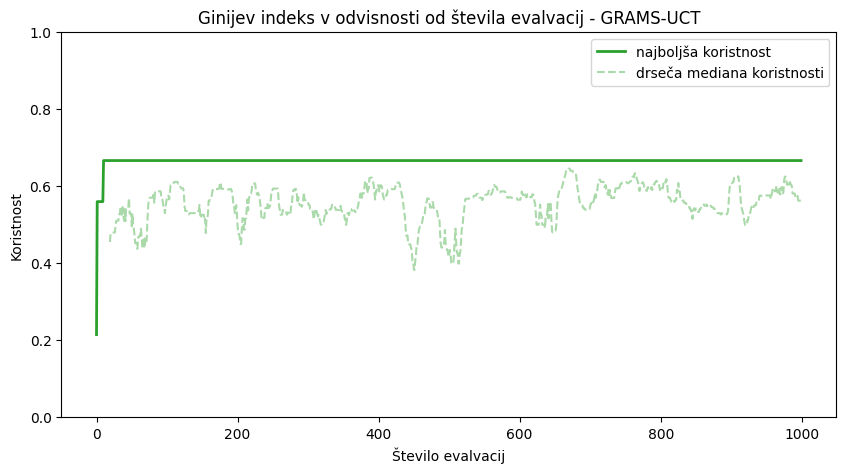

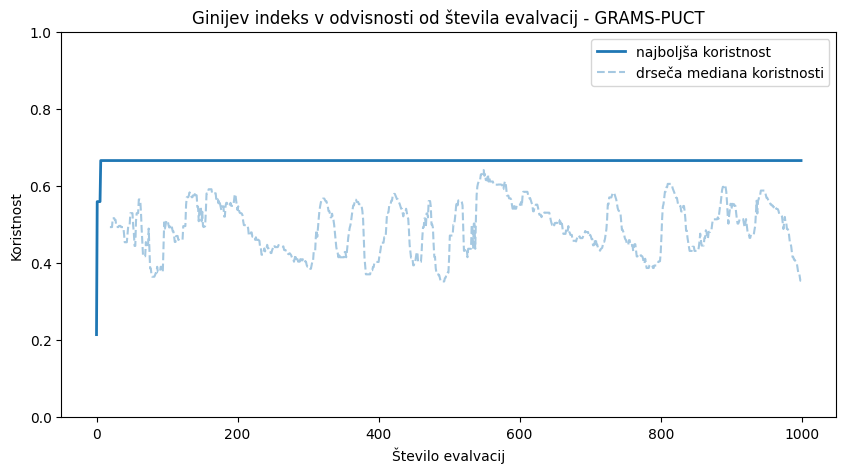

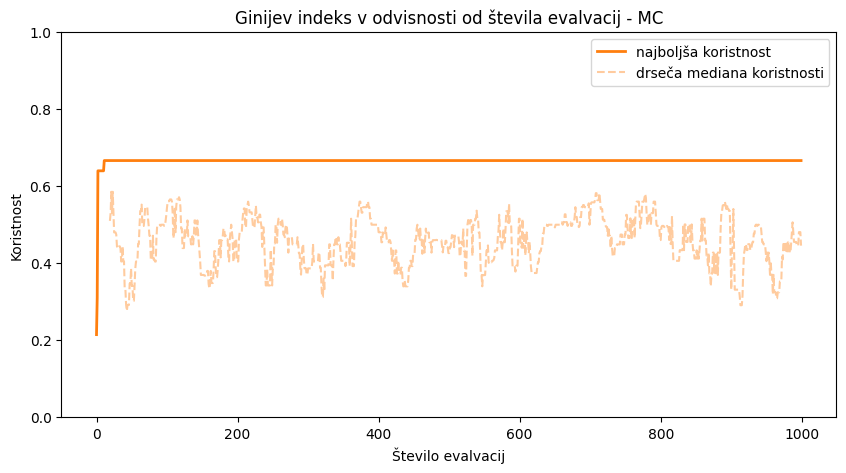

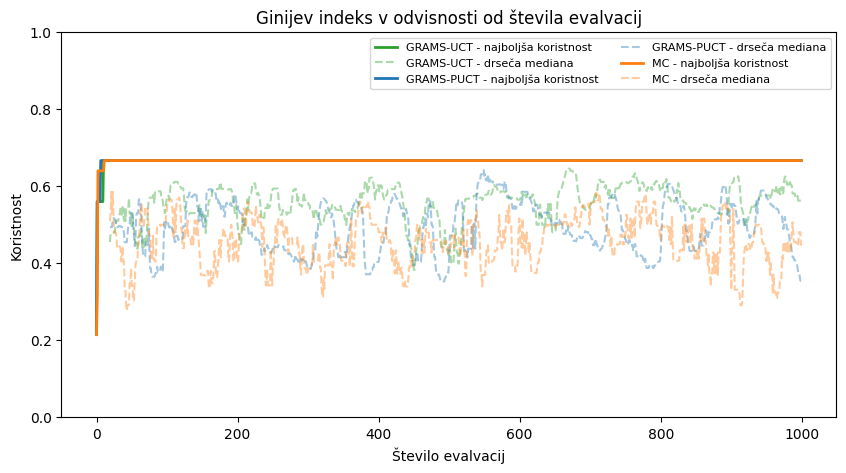

In [108]:
grammar = Grammar.from_grammar_string(grammar_str, start="E")
max_depth = 100
tree_search_puct = Grams(grammar, reward=gini_impurity, max_depth=max_depth)
tree_search_uct = Grams(grammar, reward=gini_impurity, max_depth=max_depth, use_puct=False)

results_grams_uct = tree_search_uct.search(N, random_seed=RS)
results_grams_puct = tree_search_puct.search(N, random_seed=RS)
results_mc, rule_history_mc = mc_search(grammar, N, gini_impurity, random_seed=RS)

for label, res in [("GRAMS-PUCT", results_grams_puct), ("GRAMS-UCT", results_grams_uct), ("MC", results_mc)]:
    best_expr, best_reward, _ = max(res, key=lambda r: r[1])
    print(f"{label} najboljša nagrada = {best_reward:.3f}   "
          f"mediana = {np.median([r[1] for r in res]):.3f}   najboljši niz = {best_expr}")

plot_progress(results_grams_uct, name="Ginijev indeks v odvisnosti od števila evalvacij - GRAMS-UCT", ylim=(0,1), method="GRAMS-UCT", save_name="gini_grams_uct.png")
plot_progress(results_grams_puct, name="Ginijev indeks v odvisnosti od števila evalvacij - GRAMS-PUCT", ylim=(0,1), method="GRAMS-PUCT", save_name="gini_grams_puct.png")
plot_progress(results_mc, name="Ginijev indeks v odvisnosti od števila evalvacij - MC", ylim=(0,1), method="MC", save_name="gini_mc.png")

plot_progress_combined(
    {"GRAMS-UCT": results_grams_uct, "GRAMS-PUCT": results_grams_puct, "MC": results_mc},
    name="Ginijev indeks v odvisnosti od števila evalvacij",
    ylim=(0, 1),
    save_name="gini_index_primerjava.png",
)

In [ ]:
tree_search_puct = Grams(grammar, reward=gini_reward, max_depth=max_depth, c_param=1.2)
tree_search_uct = Grams(grammar, reward=gini_reward, max_depth=max_depth, use_puct=False)

results_grams_uct = tree_search_uct.search(N, random_seed=RS)
results_grams_puct = tree_search_puct.search(N, random_seed=RS)
results_mc, rule_history_mc = mc_search(grammar, N, gini_reward, random_seed=RS)

for label, res in [("GRAMS-PUCT", results_grams_puct), ("GRAMS-UCT", results_grams_uct),("MC", results_mc)]:
    best_expr, best_reward, _ = max(res, key=lambda r: r[1])
    print(f"{label} najboljša nagrada = {best_reward:.3f}   "
          f"mediana = {np.median([r[1] for r in res]):.3f}   najboljši niz = {best_expr}")

plot_progress_combined(
    {"GRAMS-UCT": results_grams_uct, "GRAMS-PUCT": results_grams_puct, "MC": results_mc},
    name="Funkcije koristnosti U v odvisnosti od števila evalvacij",
    ylim=(0, 6),
    save_name="utility_primerjava.png",
)

GRAMS-PUCT najboljša nagrada = 3.555   mediana = 0.292   najboljši niz = aaaabbbbbccccc
GRAMS-UCT najboljša nagrada = 4.362   mediana = 0.780   najboljši niz = aaaaaabbbbbbbccccccc
MC najboljša nagrada = 2.860   mediana = 0.077   najboljši niz = aaabbbcccc


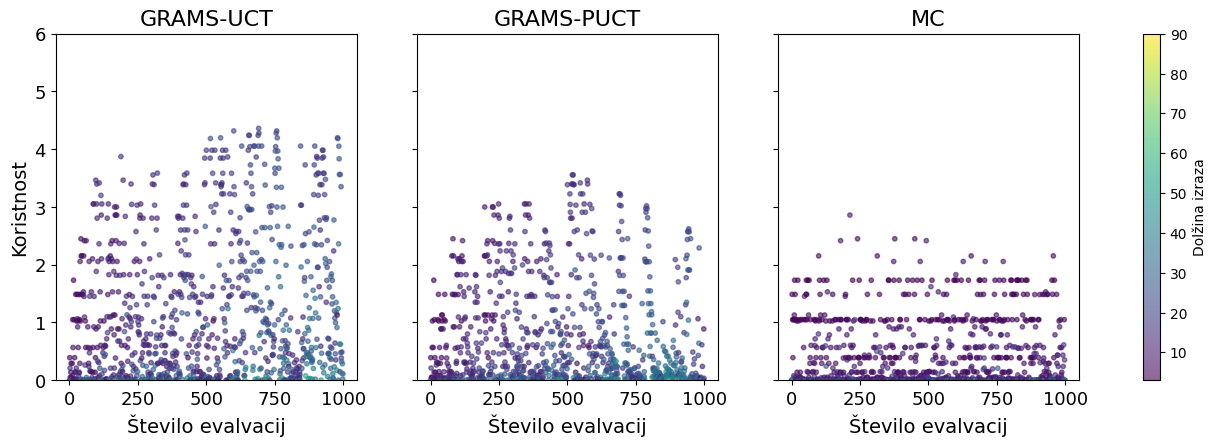

In [111]:
plot_reward_scatter({
    "GRAMS-UCT": results_grams_uct,
    "GRAMS-PUCT": results_grams_puct,
    "MC": results_mc
}, save_name="reward_scatter.png", ylim=(0,6))

In [112]:
K = 3
all_methods = {
    "GRAMS-PUCT": run_n_times(
        lambda random_seed: tree_search_puct.search(N, random_seed=random_seed)
    ),
    "GRAMS-UCT": run_n_times(
        lambda random_seed: tree_search_uct.search(N, random_seed=random_seed)
    ),
    "MC": run_n_times(
        lambda random_seed: mc_search(grammar, N, gini_reward, random_seed=random_seed)[0]
    ),
    "GRAMS-PUCT_5": run_n_times(
        lambda random_seed: tree_search_puct.search(N // K, random_seed=random_seed,
                                                    k_rollouts=K)
    ),
    "GRAMS-UCT_5": run_n_times(
        lambda random_seed: tree_search_uct.search(N // K, random_seed=random_seed,
                                                    k_rollouts=K)
    ),
}


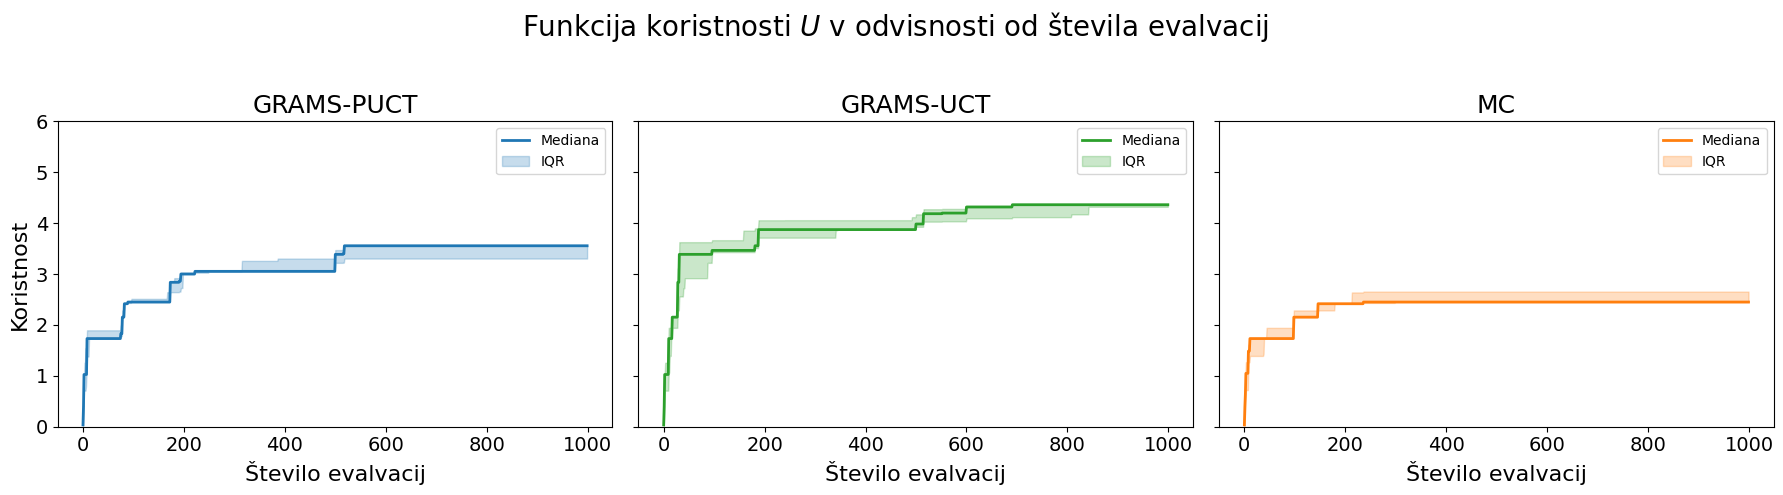

In [113]:
def plot_progress_n_runs(all_results, name, method=None, ylim=(0, 6), save_name=None, ax=None):
    color = METHOD_COLORS[method]
    runs = [np.maximum.accumulate([item[1] for item in results]) for results in all_results]

    max_len = max(len(r) for r in runs)
    runs = np.array([
        np.pad(r, (0, max_len - len(r)), mode="edge")
        for r in runs
    ])

    median = np.median(runs, axis=0)
    q1 = np.percentile(runs, 25, axis=0)
    q3 = np.percentile(runs, 75, axis=0)
    x = np.arange(max_len)

    own_fig = ax is None
    if own_fig:
        plt.figure(figsize=(10, 5))
        ax = plt.gca()

    ax.plot(x, median, linewidth=2, label="Mediana", color=color)
    ax.fill_between(x, q1, q3, alpha=0.25, label="IQR", color=color)
    ax.set_ylim(*ylim)
    ax.set_title(name, fontsize=18)
    ax.set_xlabel("Število evalvacij", fontsize=16)
    ax.set_ylabel("Koristnost", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.legend()

    if own_fig:
        if save_name:
            plt.savefig(f"{save_dir}{save_name}", dpi=300, bbox_inches='tight')
        plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    (all_methods["GRAMS-PUCT"], "GRAMS-PUCT", "GRAMS-PUCT"),
    (all_methods["GRAMS-UCT"],  "GRAMS-UCT",  "GRAMS-UCT"),
    (all_methods["MC"],         "MC",         "MC"),
]

for i, (ax, (results, title, method)) in enumerate(zip(axes, configs)):
    plot_progress_n_runs(results, title, method=method, ax=ax)
    if i != 0:
        ax.set_ylabel("")
fig.suptitle("Funkcija koristnosti $U$ v odvisnosti od števila evalvacij", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.94])  
plt.savefig(f"{save_dir}utility_all_n_runs.png", dpi=300, bbox_inches="tight")
plt.show()

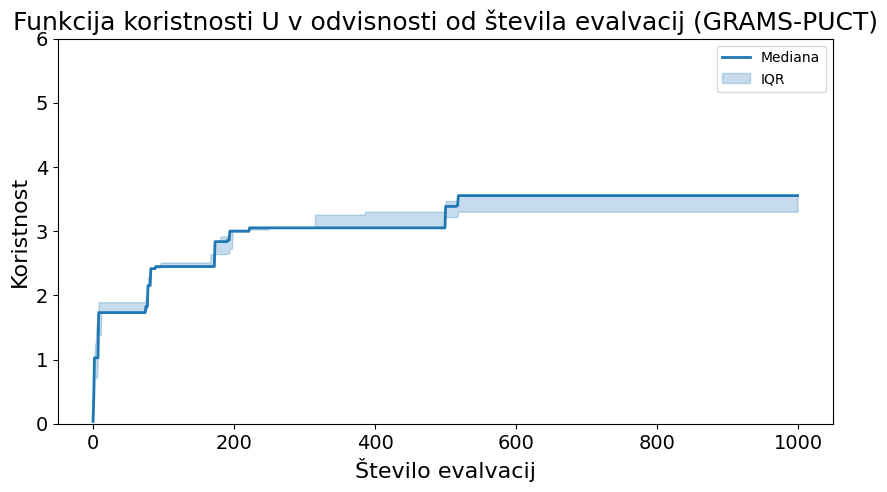

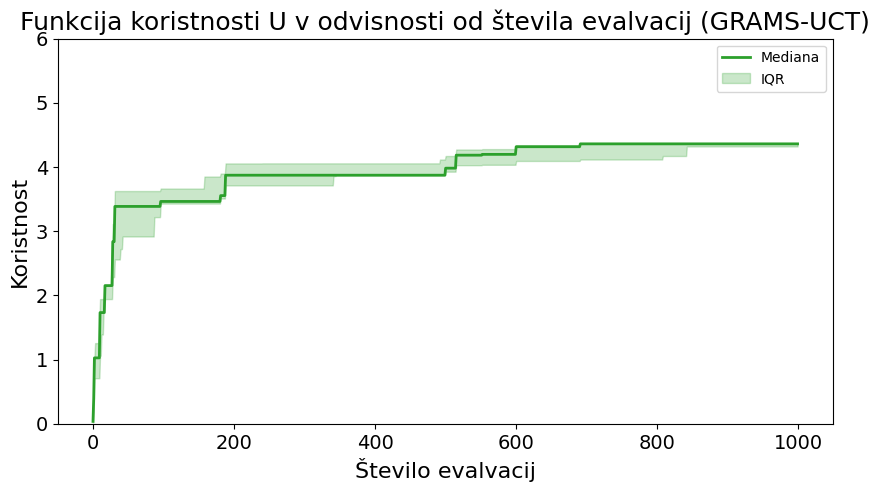

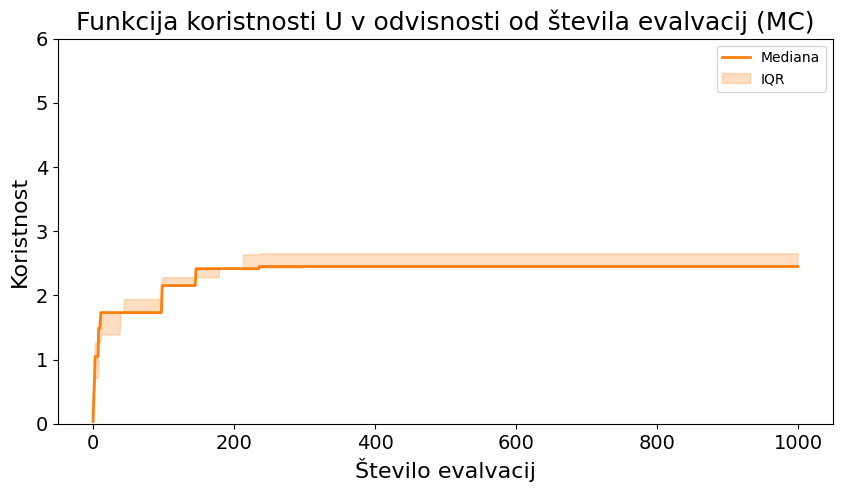

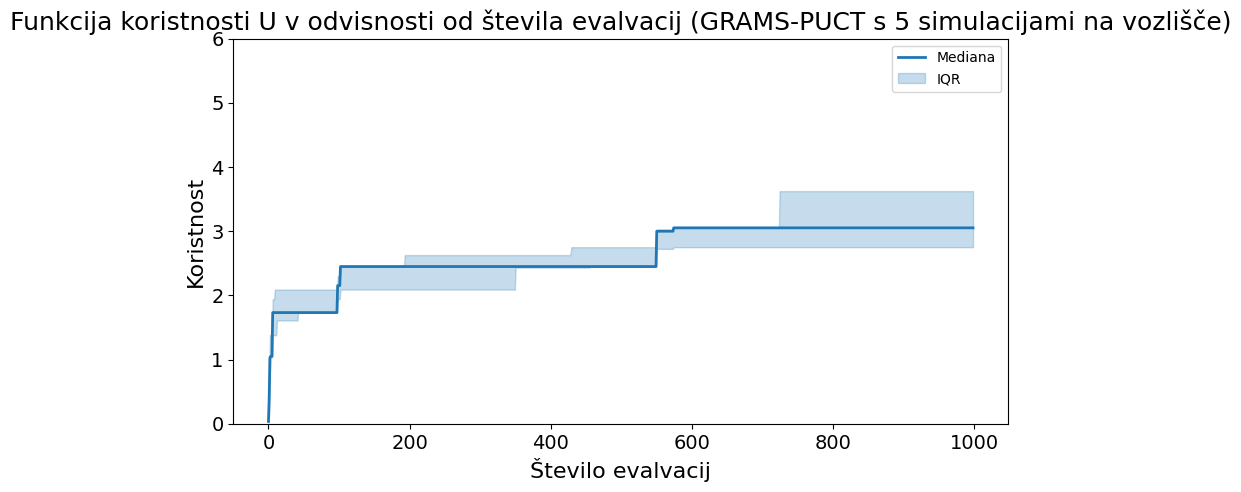

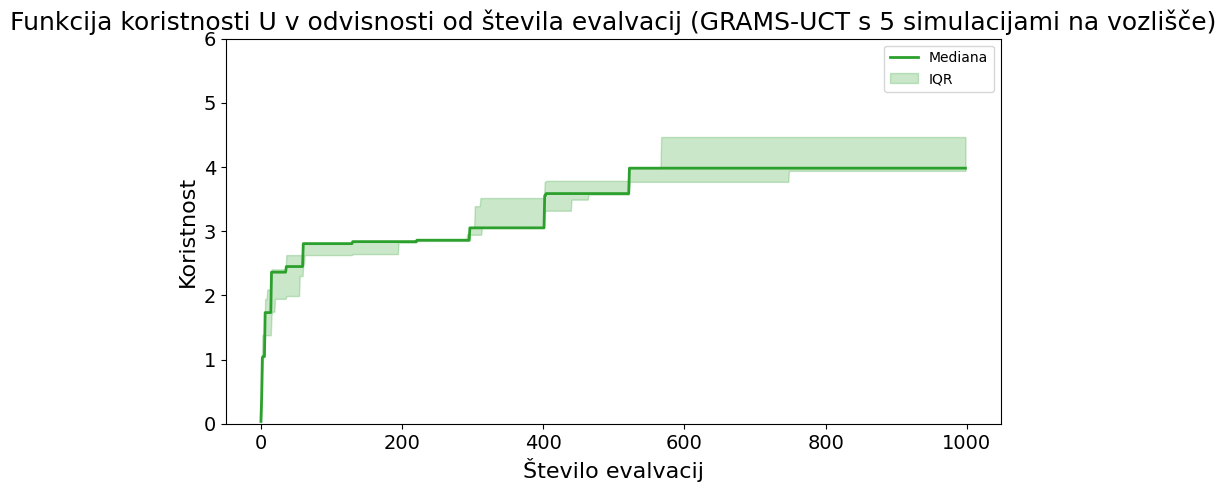

In [ ]:
plot_progress_n_runs(all_methods["GRAMS-PUCT_5"], "Funkcija koristnosti U v odvisnosti od števila evalvacij (GRAMS-PUCT s 5 simulacijami na vozlišče)", method="GRAMS-PUCT", save_name="utility_grams_puct_5_n_runs.png")
plot_progress_n_runs(all_methods["GRAMS-UCT_5"], "Funkcija koristnosti U v odvisnosti od števila evalvacij (GRAMS-UCT s 5 simulacijami na vozlišče)", method="GRAMS-UCT", save_name="utility_grams_uct_5_n_runs.png")

In [ ]:
METHOD_COLORS["GRAMS-UCT_5"] = "tab:red"
METHOD_COLORS["GRAMS-PUCT_5"] = "tab:pink"

def compare_methods_progress_split(all_methods, save_name="primerjava_metod_split", ylim=(0, 6)):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    groups = [
        ("UCT in UCT_5", ["GRAMS-UCT", "GRAMS-UCT_5"]),
        ("PUCT in PUCT_5", ["GRAMS-PUCT", "GRAMS-PUCT_5"]),
        ("UCT in PUCT in MC", ["GRAMS-UCT", "GRAMS-PUCT", "MC"]),
    ]

    for ax, (title, labels) in zip(axes, groups):
        for label in labels:
            all_results = all_methods[label]
            color = METHOD_COLORS[label]
            runs = [np.maximum.accumulate([item[1] for item in r]) for r in all_results]
            max_len = max(len(r) for r in runs)
            runs = np.array([np.pad(r, (0, max_len - len(r)), mode="edge") for r in runs])
            ax.plot(np.arange(max_len), np.median(runs, axis=0), color=color, linewidth=2, label=label)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Število evalvacij", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=12)

    axes[0].set_ylabel("Koristnost", fontsize=16)
    fig.suptitle("Primerjava metod", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"{save_dir}{save_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

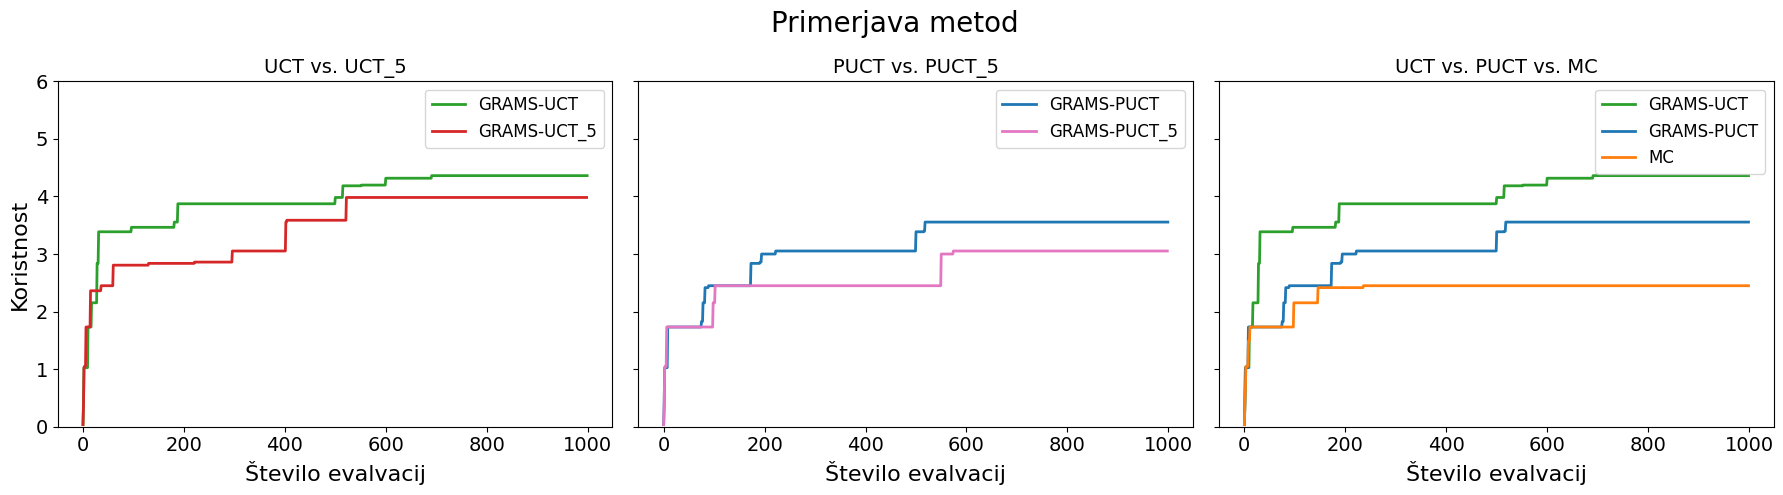

In [116]:
compare_methods_progress_split(all_methods)

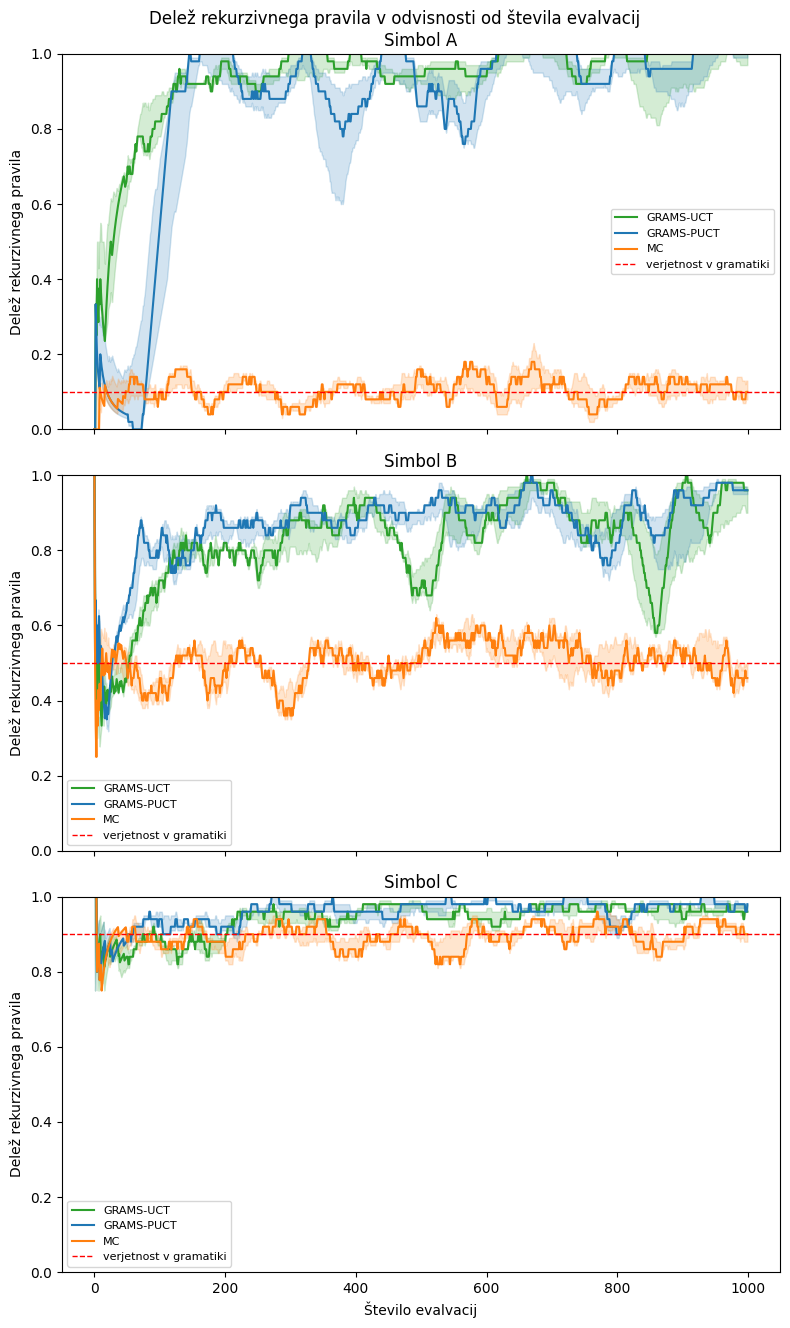

In [ ]:
def recursive_flags(rule_history, symbol):
    """Za vsak izraz označi (1/0), ali je bilo za dani simbol uporabljeno rekurzivno pravilo."""
    flags = []
    for rules in rule_history:
        lhs_rules = [r for r in rules if str(r.lhs) == symbol]
        if not lhs_rules:
            continue
        is_recursive = any(symbol in [str(s) for s in r.rhs] for r in lhs_rules)
        flags.append(1 if is_recursive else 0)
    return flags


def plot_rule_frequency_grid_n_runs(rule_histories_grams_uct, rule_histories_grams_puct, rule_histories_mc, target_probs, name="", window=50):
    """Nariše delež uporabe rekurzivnih pravil po simbolih za posamezne metode."""
    symbols = list(target_probs.keys())
    fig, axes = plt.subplots(len(symbols), 1, figsize=(8, 4.5 * len(symbols)), sharex=True)
    if len(symbols) == 1:
        axes = [axes]

    def aggregate(rule_histories, symbol):
        curves = []
        for rh in rule_histories:
            ma = pd.Series(recursive_flags(rh, symbol)).rolling(window=window, min_periods=1).mean().to_numpy()
            curves.append(ma)
        max_len = max(len(c) for c in curves)
        padded = np.array([np.pad(c, (0, max_len - len(c)), constant_values=np.nan) for c in curves])
        return np.nanmedian(padded, axis=0), np.nanpercentile(padded, 25, axis=0), np.nanpercentile(padded, 75, axis=0)

    methods = [
        ("GRAMS-UCT", rule_histories_grams_uct, "tab:green"),
        ("GRAMS-PUCT", rule_histories_grams_puct, "tab:blue"),
        ("MC", rule_histories_mc, "tab:orange"),
    ]

    for ax, symbol in zip(axes, symbols):
        for label, rule_histories, color in methods:
            med, q1, q3 = aggregate(rule_histories, symbol)
            ax.plot(med, color=color, label=f"{label}")
            ax.fill_between(range(len(med)), q1, q3, color=color, alpha=0.2)

        ax.axhline(y=target_probs[symbol], color="red", linestyle="--", linewidth=1, label="verjetnost v gramatiki")
        ax.set_title(f"Simbol {symbol}")
        ax.set_ylabel("Delež rekurzivnega pravila")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)

    axes[-1].set_xlabel("Število evalvacij")   
    fig.suptitle(f"Delež rekurzivnega pravila v odvisnosti od števila evalvacij")
    plt.tight_layout()
    plt.savefig(f"{save_dir}{name}_rule_frequency_grid_n_runs.png", dpi=300, bbox_inches="tight")
    plt.show()


rule_histories_mc, rule_histories_grams_uct, rule_histories_grams_puct = [], [], []
for seed in range(3):
    grammar = Grammar.from_grammar_string(grammar_str, start="E")
    _, rh_mc = mc_search(grammar, N, gini_reward, random_seed=seed)
    rule_histories_mc.append(rh_mc)

    tree = Grams(grammar, reward=gini_reward, max_depth=max_depth, use_puct=False)
    tree.search(N, random_seed=seed)
    rule_histories_grams_uct.append(tree.rule_history)

    tree = Grams(grammar, reward=gini_reward, max_depth=max_depth, use_puct=True)
    tree.search(N, random_seed=seed)
    rule_histories_grams_puct.append(tree.rule_history)

plot_rule_frequency_grid_n_runs(rule_histories_grams_uct, rule_histories_grams_puct, rule_histories_mc,
                                 target_probs={"A": p_a, "B": p_b, "C": p_c}, name="grammar")

### Analiza: Feynman

In [4]:
feynman_results = pd.read_pickle("nova_verzija_percentilna.pkl")
feynman_results = feynman_results.sort_values(by=["equation_id", "method", "reward_function", "seed"])

# že zagnano
# def simplify_row(row):
#     if row["expr_tokens"] is None:
#         return None
#     lib = SymbolLibrary.default_symbols(num_variables=int(row["n_variables"]))
#     try:
#         return "".join(simplify(row["expr_tokens"], symbol_library=lib))  
#     except Exception as e:
#         print(f"[napaka] {row['equation_id']}/{row['seed']}: {e}")
#         return None

# feynman_results["best_expr_simplified"] = feynman_results.apply(simplify_row, axis=1)

# feynman_results.to_pickle("nova_verzija_percentilna.pkl")
# feynman_results.to_csv("nova_verzija_percentilna.csv", index=False)


In [5]:
solve_rate_by_seed = (
    feynman_results
    .groupby(["method", "seed", "reward_function"])["success"]
    .agg(resenih="sum", skupaj="count")
)
solve_rate_by_seed

resenih  skupaj
method     seed reward_function                 
GRAMS-PUCT 0    BIC                   18     100
                RMSE                  18     100
           1    BIC                   20     100
                RMSE                  17     100
           2    BIC                   22     100
                RMSE                  21     100
GRAMS-UCT  0    BIC                   24     100
                RMSE                  24     100
           1    BIC                   24     100
                RMSE                  19     100
           2    BIC                   25     100
                RMSE                  26     100
MC         0    N/A                   23     100
           1    N/A                   21     100
           2    N/A                   18     100

In [ ]:
def summarize_methods(df):
    """Sestavi povzetek uspešnosti metod (delež rešenih, mediana napake ipd.)."""
    rows = []
    for (method, reward_function), sub in df.groupby(["method", "reward_function"]):
        solved = sub[sub["success"]]
        rows.append({
            "metoda": method,
            "funkcija nagrajevanja": reward_function,
            "rešenih": int(sub["success"].sum()),
            "vseh": len(sub),
            "delež rešenih": f"{sub['success'].mean():.3f}",
            "mediana min_error": f"{sub['min_error'].replace(np.inf, np.nan).median():.4f}",
            "povprečje evalvacij do uspeha": f"{solved['evaluation_calls'].mean():.1f}"
                                            if len(solved) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("delež rešenih", ascending=False).reset_index(drop=True)


summary = summarize_methods(feynman_results)
summary

,metoda,funkcija nagrajevanja,rešenih,vseh,delež rešenih,mediana min_error,mediana evalvacij do uspeha
0,GRAMS-UCT,BIC,73,300,0.243,0.0807,1662.6
1,GRAMS-UCT,RMSE,69,300,0.230,0.0746,1518.2
2,MC,N/A,62,300,0.207,0.1381,1976.2
3,GRAMS-PUCT,BIC,60,300,0.200,0.1202,1820.5
4,GRAMS-PUCT,RMSE,56,300,0.187,0.1139,1959.4


In [ ]:
# seznam za DODATEK v magistrskem delu
cols = ["equation_id", "method", "reward_function", "seed", "min_error", "success", "best_expr_simplified"]

# zmanjšamo best_expr_simplified
def escape_and_wrap_expr(s):
    if s is None:
        return ""
    s = str(s)
    replacements = [
        ("\\", r"\textbackslash{}"),
        ("_", r"\_"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("&", r"\&"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("^", r"\textasciicircum{}"),   
        ("~", r"\textasciitilde{}"),    
    ]
    for orig, repl in replacements:
        s = s.replace(orig, repl)
    return f"\\seqsplit{{{s}}}"

feynman_results["best_expr_simplified"] = feynman_results["best_expr_simplified"].apply(escape_and_wrap_expr)
feynman_results[cols].to_latex(
    "tabela_rezultatov.tex",
    index=False,
    longtable=True,      
    float_format="%.2e",
    escape=False,
)

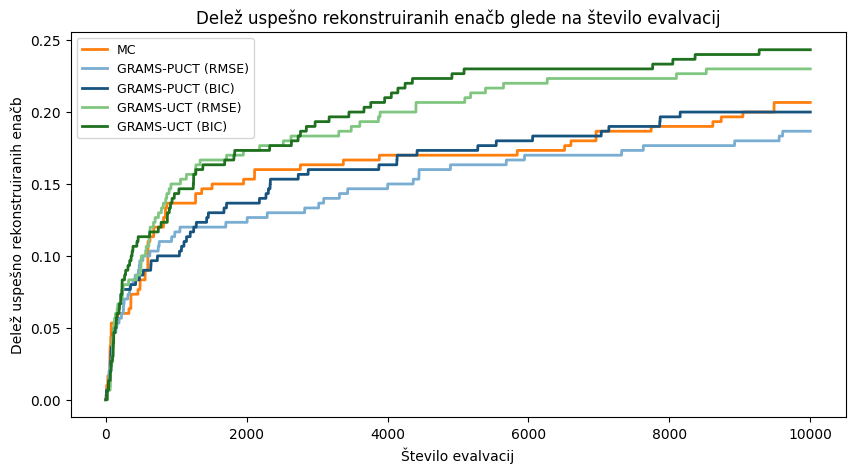

In [169]:
plot_solve_rate_vs_iterations(feynman_results, max_iterations=10000)

In [ ]:
def plot_complexity_boxplot(df):
    """Nariše škatlo z brki glede na kompleksnosti enačb za uspešne in neuspešne zagone."""
    df = df.copy()
    df["complexity"] = df["ground_truth"].apply(
        lambda g: len(g) if g is not None else np.nan)

    methods = list(df["method"].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5), sharey=True)
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        sub = df[df["method"] == method]
        solved = sub[sub["success"]]["complexity"].dropna().values
        unsolved = sub[~sub["success"]]["complexity"].dropna().values
        ax.boxplot([solved, unsolved], tick_labels=["uspešno", "neuspešno"])
        for label in ax.get_xticklabels():
            label.set_fontsize(14)
        ax.set_title(method, fontsize=16)
        ax.tick_params(axis="both", labelsize=14)
    axes[0].set_ylabel("Kompleksnost enačbe", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{save_dir}complexity_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

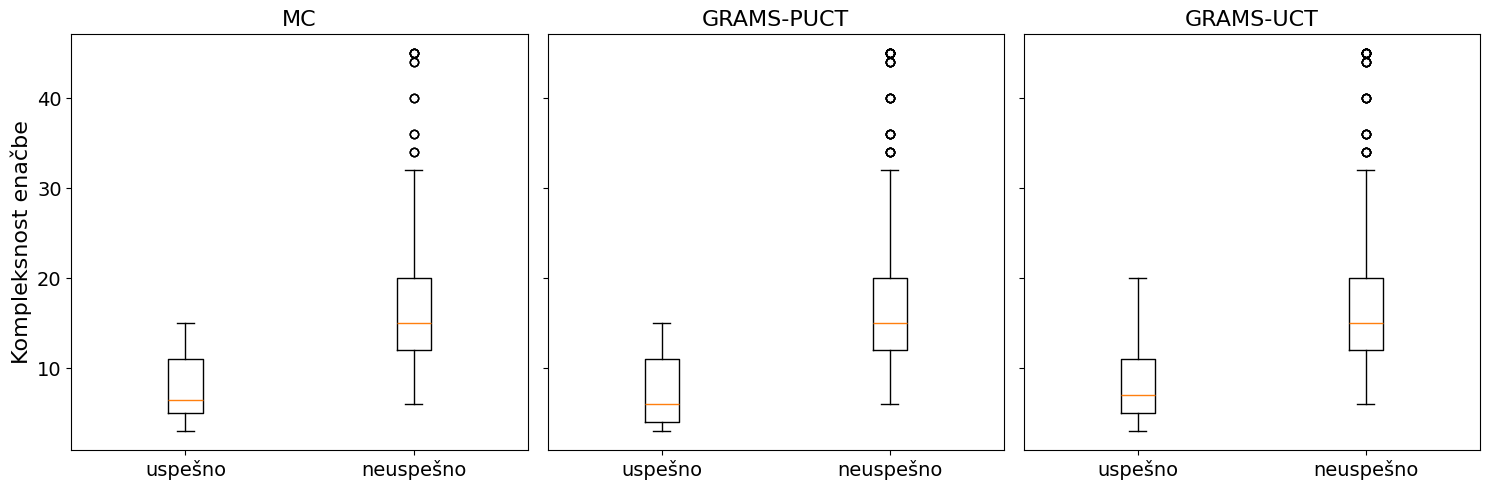

In [170]:
plot_complexity_boxplot(feynman_results)

In [8]:
mc_solved = set(feynman_results[(feynman_results["method"] == "MC") & feynman_results["success"]]["equation_id"])
grams_uct_solved = set(feynman_results[(feynman_results["method"].str.startswith("GRAMS-UCT")) & feynman_results["success"]]["equation_id"])
grams_puct_solved = set(feynman_results[(feynman_results["method"].str.startswith("GRAMS-PUCT")) & feynman_results["success"]]["equation_id"])

both = mc_solved & grams_uct_solved
only_mc = mc_solved - grams_uct_solved
only_grams = grams_uct_solved - mc_solved
n_total_solved = len(mc_solved | grams_uct_solved)

both_grams = grams_uct_solved & grams_puct_solved

print("PRIMERJAVA MED GRAMS-UCT in MC:")
print(f"Rešeno z obema pristopoma:      {len(both):3d}  ({len(both)/n_total_solved*100:.1f}% vseh rešenih)")
print(f"Rešeno SAMO z MC:                {len(only_mc):3d}  ({len(only_mc)/n_total_solved*100:.1f}%)")
print(f"Rešeno SAMO z GRAMS-UCT:  {len(only_grams):3d}  ({len(only_grams)/n_total_solved*100:.1f}%)")
print("Enačbe, rešene SAMO z MC:", sorted(only_mc))
print("Enačbe, rešene SAMO z GRAMS-UCT:", sorted(only_grams))
print()
print("PRIMERJAVA MED GRAMS-UCT in GRAMS-PUCT:")
print("Enačbe, rešene z obema GRAMS pristopoma:", len(both_grams))
print("Enačbe, rešene SAMO z GRAMS-UCT:", len(grams_uct_solved - grams_puct_solved))
print("Enačbe, rešene SAMO z GRAMS-PUCT:", len(grams_puct_solved - grams_uct_solved))

PRIMERJAVA MED GRAMS-UCT in MC:
Rešeno z obema pristopoma:       24  (72.7% vseh rešenih)
Rešeno SAMO z MC:                  1  (3.0%)
Rešeno SAMO z GRAMS-UCT:    8  (24.2%)
Enačbe, rešene SAMO z MC: ['I.47.23']
Enačbe, rešene SAMO z GRAMS-UCT: ['I.18.12', 'I.18.14', 'I.34.8', 'I.43.16', 'II.13.17', 'II.34.11', 'II.37.1', 'III.21.20']

PRIMERJAVA MED GRAMS-UCT in GRAMS-PUCT:
Enačbe, rešene z obema GRAMS pristopoma: 26
Enačbe, rešene SAMO z GRAMS-UCT: 6
Enačbe, rešene SAMO z GRAMS-PUCT: 3


In [ ]:
def substitute_fitted_constants_tokens(expr_tokens, parameters):
    """Zamenja simbole 'C' v izrazu z ustreznimi prilagojenimi vrednostmi parametrov."""
    params_iter = iter(parameters if parameters is not None else [])
    out = []
    for t in expr_tokens:
        if t == "C":
            try:
                out.append(f"{next(params_iter):.6g}")   
            except StopIteration:
                out.append(t)
        else:
            out.append(t)
    return out


def replace_pi_with_C(tokens):
    """Zamenja vse pojave simbola 'pi' s simbolom 'C' v seznamu tokenov."""
    return ["C" if t == "pi" else t for t in tokens]


def build_reconstruction_check_table(results_df, error_threshold=1e-7):
    """Sestavi tabelo za preverjanje rekonstrukcije enačb glede na prag napake RMSE."""
    rows = []
    candidates = results_df[
        (results_df["min_error"] < error_threshold)
        & results_df["ground_truth"].notna()
        & results_df["expr_tokens"].notna()
    ]

    for _, row in candidates.iterrows():
        n_vars = int(row["n_variables"])
        lib = SymbolLibrary.default_symbols(num_variables=n_vars)
        gt_tokens = list(row["ground_truth"])
        expr_tokens = list(row["expr_tokens"])  
        expr_tokens_fitted = substitute_fitted_constants_tokens(expr_tokens, row["expr_params"])

        try:
            gt_simpl_str = "".join(simplify(replace_pi_with_C(gt_tokens), symbol_library=lib))
        except Exception as e:
            gt_simpl_str = "".join(gt_tokens)
            print(f"[simplify: resnicna] {row['equation_id']}: {e}")

        try:
            ex_simpl_str = "".join(simplify(replace_pi_with_C(expr_tokens), symbol_library=lib))
        except Exception as e:
            ex_simpl_str = "".join(expr_tokens)
            print(f"[simplify: odkrita] {row['equation_id']}: {e}")

        rows.append({
            "equation_id": row["equation_id"],
            "method": row["method"],
            "seed": row["seed"],
            "min_error": row["min_error"],
            "odkrita_formula": "".join(expr_tokens),
            "odkrita_formula_s_parametri": "".join(expr_tokens_fitted),
            "odkrita_poenostavljena": ex_simpl_str,
            "resnicna_poenostavljena": gt_simpl_str,
        })

    out = pd.DataFrame(rows)
    if len(out) > 0:
        out = out.sort_values("min_error").reset_index(drop=True)
    return out

error_threshold = 1e-7
check_table = build_reconstruction_check_table(feynman_results, error_threshold=error_threshold)
if len(check_table) == 0:
    print(f"Noben zagon ni dosegel praga RMSE < {error_threshold} — ni kaj preverjati.")
else:
    print(f"Kandidatov z RMSE < {error_threshold}: {len(check_table)}")
    check_table[["equation_id", "method", "min_error",
                 "resnicna_poenostavljena", "odkrita_poenostavljena",
                 "odkrita_formula", "odkrita_formula_s_parametri"]].to_csv(f"{save_dir}reconstruction_check_table.csv", index=False)

Kandidatov z RMSE < 1e-07: 320


Analiziramo dva primera enačbe iz Feynmanove podatkovne množice

In [ ]:
def run_single(name, seed, c_param, iterations, k_rollouts, max_depth, use_puct, reward):
    """Zažene en zagon iskanja za dano enačbo in vrne rezultat ter zgodovino."""
    benchmark = Feynman()
    dataset = benchmark.create_dataset(name, seed=seed)
    n_vars = dataset.X.shape[1]
    error_threshold = dataset.success_threshold or 1e-7
    grammar_str = build_grammar(n_vars)
    grammar = Grammar.from_grammar_string(grammar_str, start="E")
    lib = SymbolLibrary.default_symbols(num_variables=n_vars)
    evaluator = SR_evaluator(X=dataset.X, y=dataset.y, symbol_library=lib,
                              max_evaluations=iterations, seed=seed,
                              success_threshold=error_threshold)
    grams = Grams(grammar=grammar, reward=reward, evaluator=evaluator,
                 max_depth=max_depth, c_param=c_param, use_puct=use_puct, error=error_threshold)
    results = grams.search(iterations=iterations, random_seed=seed, k_rollouts=k_rollouts)
    r0 = results[0]
    return {
        "c_param": c_param, "seed": seed,
        "min_rmse": r0.min_error, "success": r0.success,
        "history": grams.history, "best_expr": r0.best_expr,
        "evaluation_calls": r0.evaluation_calls,          
        "n_history": len(grams.history),                 
    }

def test_c_param(name, c_params, seeds=range(3), iterations=50000, k_rollouts=3, max_depth=50, use_puct=False, reward=reward_function_bic, n_jobs=-2):
    """Preizkusi različne vrednosti parametra c za dano enačbo in vrne povzetek rezultatov."""
    tasks = [(c, s) for c in c_params for s in seeds]

    all_results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(run_single)(name, seed, c_param, iterations, k_rollouts, max_depth, use_puct, reward)
        for c_param, seed in tasks
    )

    rows, curves = [], {}
    for c_param in c_params:
        c_results = [r for r in all_results if r["c_param"] == c_param]

        curves_per_seed = []
        for r in c_results:
            rmses = [entry[2] if entry[2] is not None and np.isfinite(entry[2]) else np.inf
                     for entry in r["history"]]
            curves_per_seed.append(np.minimum.accumulate(rmses) if rmses else np.array([np.inf]))
        max_len = max(len(c) for c in curves_per_seed)
        padded = np.array([np.pad(c, (0, max_len - len(c)), mode="edge") for c in curves_per_seed])
        curves[c_param] = {
            "median": np.median(padded, axis=0),
            "q1": np.percentile(padded, 25, axis=0),
            "q3": np.percentile(padded, 75, axis=0),
        }

        min_rmses = [r["min_rmse"] for r in c_results]
        successes = [r["success"] for r in c_results]
        eval_calls = [r["evaluation_calls"] for r in c_results]   
        n_history = [len(r["history"]) for r in c_results]        

        rows.append({
            "c_param": c_param,
            "best_quality": np.median(min_rmses),
            "best_quality_min": np.min(min_rmses),
            "success": any(successes),
            "success_rate": np.mean(successes),
            "n_seeds": len(list(seeds)),
            "median_evaluation_calls": np.median(eval_calls),     
            "median_n_history": np.median(n_history),               
            "delez_neuspelih": 1 - np.median(n_history) / np.median(eval_calls),   
        })

    return pd.DataFrame(rows), curves

In [ ]:
def plot_c_param(name, curves_full, threshold=None, save_name=None):
    """Nariše potek najmanjšega RMSE za različne vrednosti C_UCT."""
    plt.figure(figsize=(10, 5.5))
    c_params = sorted(curves_full)
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(c_params)))

    for c_param, color in zip(c_params, colors):
        c = curves_full[c_param]
        plt.plot(c['median'], color=color, linewidth=1.8, label=f"$C_{{UCT}}$ = {c_param}")
        plt.fill_between(range(len(c['median'])), c['q1'], c['q3'], color=color, alpha=0.12)

    if threshold is not None:
        plt.axhline(y=threshold, color="red", linestyle="--", linewidth=1,
                   label=f"prag uspeha ({threshold:.0e})")
    plt.yscale("log")
    plt.ylabel("Najmanjši RMSE doslej (log)", fontsize=13)
    plt.xlabel("Število uspešno ovrednotenih izrazov", fontsize=13)
    plt.title(f"Enačba {name}: RMSE v odvisnosti od števila uspešno ovrednotenih izrazov za različne $C_{{UCT}}$", fontsize=14)
    plt.legend(ncol=2, fontsize=13)
    plt.xlim(0, 20000)
    plt.ylim(1e-8, 1e3)
    plt.tight_layout()
    plt.tick_params(axis="both", labelsize=13)
    plt.savefig(f"{save_dir}{save_name}_c_param_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

In [3]:
EQ_NAME = "II.8.7"
benchmark = Feynman()
dataset = benchmark.create_dataset(EQ_NAME, seed=0)
print(dataset)

Dataset for target expression E_n = 3/5*q**2/(4*pi*epsilon*d). When evaluating your model on this dataset, you should limit your generative model to only produce expressions using the following symbols: +, -, *, /, u-, sqrt, sin, cos, exp, arcsin, tanh, ln, ^2, ^3, pi, C, X_0, X_1, X_2.
Expressions will be ranked based on the RMSE ranking function.
Expressions are deemed successful if the root mean squared error is less than 1e-07. However, we advise that you check the best performing expressions manually to ensure they are correct.
Non default limitations (extra arguments) from the SR_evaluators are: max_expr_length=50,  constant_bounds=(-5.0, 5.0).
The expressions in the dataset can contain constants/free parameters.
For other metadata, please refer to the attribute self.dataset_metadata.


In [ ]:
df_f, curves_f = test_c_param(
    name=EQ_NAME, c_params=[1, 5, 10, 50], iterations=50000,
    seeds=range(3), reward=reward_function_bic, n_jobs=7)

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


Stopping early at iteration 158 with RMSE 1.4208576877990918e-09


[Parallel(n_jobs=7)]: Done   1 tasks      | elapsed:   33.4s


Stopping early at iteration 250 with RMSE 3.577371048519605e-09
Stopping early at iteration 457 with RMSE 1.9000822709217085e-11


[Parallel(n_jobs=7)]: Done   3 out of  12 | elapsed:  1.2min remaining:  3.6min


...

[Parallel(n_jobs=7)]: Done   7 out of  12 | elapsed:  2.7min remaining:  2.0min


Stopping early at iteration 2010 with RMSE 8.044017024769411e-10
Stopping early at iteration 2058 with RMSE 2.8680919440431117e-09


[Parallel(n_jobs=7)]: Done   9 out of  12 | elapsed:  4.1min remaining:  1.4min


Stopping early at iteration 2590 with RMSE 1.989120865956156e-08
Stopping early at iteration 6435 with RMSE 2.7623266903576033e-09
Stopping early at iteration 6020 with RMSE 1.0278762063110074e-09


[Parallel(n_jobs=7)]: Done  12 out of  12 | elapsed: 11.9min finished


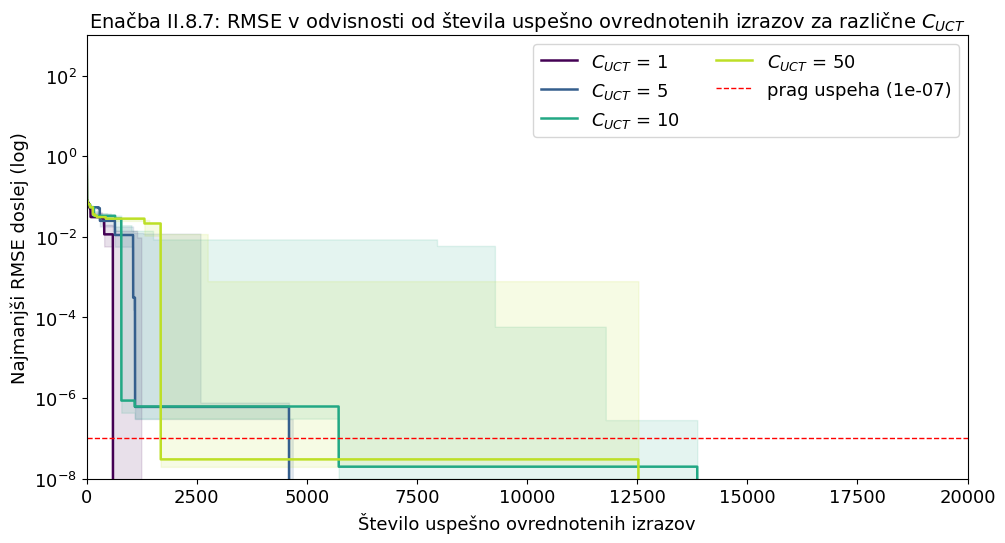

In [180]:
plot_c_param(name=EQ_NAME, curves_full=curves_f, threshold=1e-7, save_name=EQ_NAME)

In [4]:
EQ_NAME2 = "I.34.8"
benchmark = Feynman()
dataset = benchmark.create_dataset(EQ_NAME2, seed=0)
print(dataset)

Dataset for target expression omega = q*v*B/p. When evaluating your model on this dataset, you should limit your generative model to only produce expressions using the following symbols: +, -, *, /, u-, sqrt, sin, cos, exp, arcsin, tanh, ln, ^2, ^3, pi, C, X_0, X_1, X_2, X_3.
Expressions will be ranked based on the RMSE ranking function.
Expressions are deemed successful if the root mean squared error is less than 1e-07. However, we advise that you check the best performing expressions manually to ensure they are correct.
Non default limitations (extra arguments) from the SR_evaluators are: max_expr_length=50,  constant_bounds=(-5.0, 5.0).
The expressions in the dataset can contain constants/free parameters.
For other metadata, please refer to the attribute self.dataset_metadata.


In [ ]:
df_f2, curves_f2 = test_c_param(
c_params=[1, 5, 10, 50], name=EQ_NAME2, iterations=50000,
seeds=range(3), reward=reward_function_bic, n_jobs=7)

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


Stopping early at iteration 2473 with RMSE 2.6616664452586183e-08


[Parallel(n_jobs=7)]: Done   1 tasks      | elapsed:  2.9min


Stopping early at iteration 1956 with RMSE 9.116153992150509e-09
Stopping early at iteration 6318 with RMSE 1.3609585001650158e-08


[Parallel(n_jobs=7)]: Done   3 out of  12 | elapsed:  7.7min remaining: 23.1min


...

[Parallel(n_jobs=7)]: Done   5 out of  12 | elapsed: 11.9min remaining: 16.7min


Stopping early at iteration 3735 with RMSE 4.026749408746027e-09


[Parallel(n_jobs=7)]: Done   7 out of  12 | elapsed: 13.0min remaining:  9.3min
[Parallel(n_jobs=7)]: Done   9 out of  12 | elapsed: 13.4min remaining:  4.5min


Stopping early at iteration 6333 with RMSE 3.0877813397599435e-09
Stopping early at iteration 10220 with RMSE 7.703862664355014e-08
Stopping early at iteration 3986 with RMSE 1.4917699347000017e-15


[Parallel(n_jobs=7)]: Done  12 out of  12 | elapsed: 15.1min finished


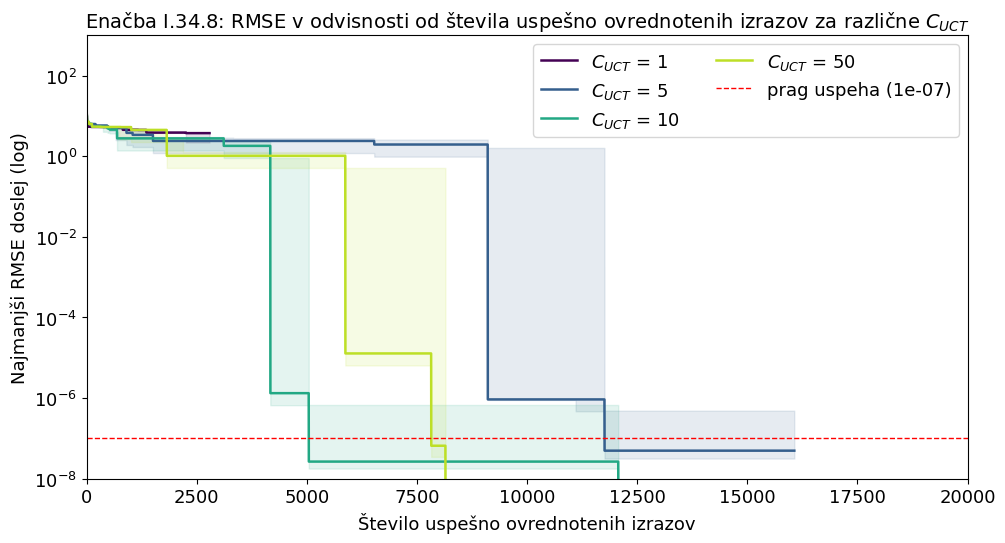

In [181]:
plot_c_param(name=EQ_NAME2, curves_full=curves_f2, threshold=1e-7, save_name=EQ_NAME2)